# Cancelaciones de Reservas Hoteleras
## ¿Las peticiones especiales son señal de compromiso real del huésped?

**Autora:** Yudy Marcela Cadena    
**Curso:** Programación y Análisis Reproducible de Datos  
**Fecha:** 9 de mayo del 2026 

---

Este notebook implementa un análisis completo y reproducible sobre las cancelaciones de reservas hoteleras, siguiendo el ciclo de vida completo del análisis de datos: desde la carga del dataset crudo hasta la generación de conclusiones accionables.

**Cómo reproducir:** Ejecutar todas las celdas en orden — `Kernel → Restart & Run All`.

---
## Sección 1 — Introducción y pregunta de análisis (10%)

### Dataset

| Atributo | Detalle |
|---|---|
| **Nombre** | Hotel Reservations Dataset |
| **Fuente** | Kaggle — Ahsan Raza |
| **URL** | https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset |
| **Licencia** | CC0 — Dominio Público |
| **Registros** | 36,275 |
| **Variables** | 19 |
| **Descarga** | Mayo 2025 |

El dataset contiene información de reservas hoteleras individuales, incluyendo características del grupo de viaje, el canal de reserva, el precio, y si la reserva fue o no cancelada.

### Pregunta de análisis

> **¿Existe una relación de dependencia estadística entre el número de peticiones especiales realizadas por un huésped y la probabilidad de cancelación de su reserva, y cómo modera el precio promedio de la habitación esta relación?**

### Hipótesis de trabajo

Un huésped que realiza peticiones especiales (tipo de habitación, almohadas, dieta especial, etc.) demuestra mayor inversión cognitiva y emocional en el viaje. Esta inversión actúa como un 'costo hundido psicológico' que reduce la probabilidad de cancelar. Adicionalmente, si el precio de la habitación es elevado, esta señal de compromiso podría ser aún más fuerte — o al contrario, el precio alto podría incentivar la cancelación en huéspedes price-sensitive.

**Esta pregunta es verificable con los datos** porque el dataset contiene exactamente las variables necesarias: `no_of_special_requests`, `avg_price_per_room` y `booking_status`.

---
## Sección 2 — Carga y exploración inicial (15%)

## Descripción del Dataset

El archivo contiene los atributos de las reservas de cada cliente. A continuación se presenta el diccionario de datos completo.

### Diccionario de Variables

| Variable | Descripción |
|:---|:---|
| `Booking_ID` | Identificador único de cada reserva |
| `no_of_adults` | Número de adultos |
| `no_of_children` | Número de niños |
| `no_of_weekend_nights` | Número de noches de fin de semana (sábado o domingo) que el huésped se hospedó o tiene reservadas |
| `no_of_week_nights` | Número de noches entre semana (lunes a viernes) que el huésped se hospedó o tiene reservadas |
| `type_of_meal_plan` | Tipo de plan de alimentación reservado por el cliente |
| `required_car_parking_space` | ¿El cliente requiere espacio de estacionamiento? (0 = No, 1 = Sí) |
| `room_type_reserved` | Tipo de habitación reservada por el cliente. Los valores están cifrados (codificados) por INN Hotels |
| `lead_time` | Número de días entre la fecha de reserva y la fecha de llegada |
| `arrival_year` | Año de la fecha de llegada |
| `arrival_month` | Mes de la fecha de llegada |
| `arrival_date` | Día del mes de llegada |
| `market_segment_type` | Segmento de mercado al que pertenece la reserva |
| `repeated_guest` | ¿El cliente es un huésped recurrente? (0 = No, 1 = Sí) |
| `no_of_previous_cancellations` | Número de reservas anteriores canceladas por el cliente antes de la reserva actual |
| `no_of_previous_bookings_not_canceled` | Número de reservas anteriores **no** canceladas por el cliente antes de la reserva actual |
| `avg_price_per_room` * | Precio promedio por noche de la reserva; los precios son dinámicos (en euros) |
| `no_of_special_requests` * | Número total de solicitudes especiales realizadas por el cliente (p. ej., piso alto, vista desde la habitación, etc.) |
| `booking_status` ** | Indicador de si la reserva fue cancelada o no *(variable objetivo)* |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import statsmodels.api as sm
import warnings

plt.style.use('seaborn-v0_8-whitegrid')  # Aplica estilo 'seaborn' a los gráficos
sns.set_palette('husl')               # Establece una paleta de colores bonita

print('Librerías cargadas correctamente.')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

Librerías cargadas correctamente.
pandas 3.0.2 | numpy 2.4.4


In [2]:
# ── Carga del dataset ──────────────────────────────────────────────────────────
DATA_PATH = '../data/raw/hotel_reservations.csv'

df_raw = pd.read_csv(DATA_PATH)

print(f'Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
df_raw.head(5)

Dimensiones: 36,275 filas × 19 columnas


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [77]:
# ── Tipos de variables y nulos ─────────────────────────────────────────────────
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  str    
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  str    
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  str    
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date              

**Nota**: Todas las columnas tienen count = 36,275 por lo que no se evidencian valores nulos (la limpieza de faltantes será mínima o nula.)

In [78]:
# ── Estadísticos descriptivos ──────────────────────────────────────────────────
df_raw.describe(include='all').round(2)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
count,36275,36275.00,36275.00,36275.00,36275.00,36275,36275.00,36275,36275.00,36275.00,36275.00,36275.00,36275,36275.00,36275.00,36275.00,36275.00,36275.00,36275
unique,36275,NaN,NaN,NaN,NaN,4,NaN,7,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,2
top,INN00001,NaN,NaN,NaN,NaN,Meal Plan 1,NaN,Room_Type 1,NaN,NaN,NaN,NaN,Online,NaN,NaN,NaN,NaN,NaN,Not_Canceled
freq,1,NaN,NaN,NaN,NaN,27835,NaN,28130,NaN,NaN,NaN,NaN,23214,NaN,NaN,NaN,NaN,NaN,24390
mean,NaN,1.84,0.11,0.81,2.20,NaN,0.03,NaN,85.23,2017.82,7.42,15.60,NaN,0.03,0.02,0.15,103.42,0.62,NaN
std,NaN,0.52,0.40,0.87,1.41,NaN,0.17,NaN,85.93,0.38,3.07,8.74,NaN,0.16,0.37,1.75,35.09,0.79,NaN
min,NaN,0.00,0.00,0.00,0.00,NaN,0.00,NaN,0.00,2017.00,1.00,1.00,NaN,0.00,0.00,0.00,0.00,0.00,NaN
25%,NaN,2.00,0.00,0.00,1.00,NaN,0.00,NaN,17.00,2018.00,5.00,8.00,NaN,0.00,0.00,0.00,80.30,0.00,NaN
50%,NaN,2.00,0.00,1.00,2.00,NaN,0.00,NaN,57.00,2018.00,8.00,16.00,NaN,0.00,0.00,0.00,99.45,0.00,NaN
75%,NaN,2.00,0.00,2.00,3.00,NaN,0.00,NaN,126.00,2018.00,10.00,23.00,NaN,0.00,0.00,0.00,120.00,1.00,NaN


### Variable objetivo
`booking_status` tiene dos categorías: `Not_Canceled` es la más frecuente con 24,390 registros. Eso implica aproximadamente 67% no canceladas vs. 33% canceladas 

In [79]:
# ── Distribución de la variable objetivo ──────────────────────────────────────
target_counts = df_raw['booking_status'].value_counts()
target_pct = df_raw['booking_status'].value_counts(normalize=True) * 100

print('Distribución de booking_status:')
for status, count in target_counts.items():
    print(f'  {status}: {count:,} ({target_pct[status]:.1f}%)')

Distribución de booking_status:
  Not_Canceled: 24,390 (67.2%)
  Canceled: 11,885 (32.8%)


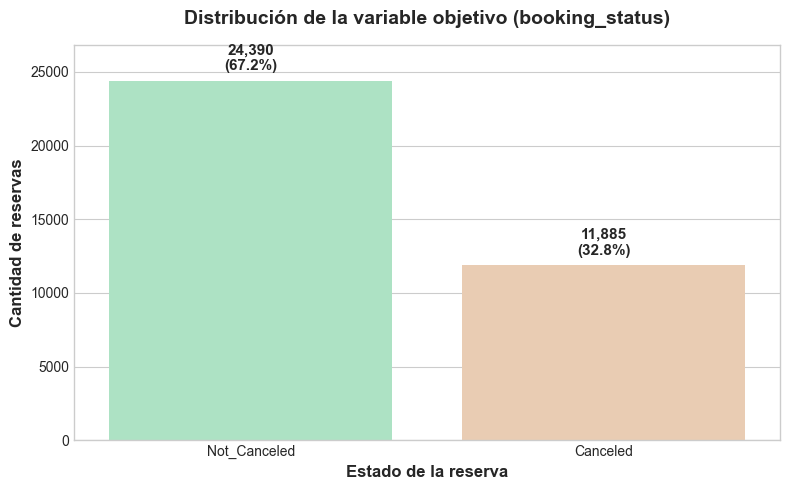

In [80]:
fig, ax = plt.subplots(figsize=(8, 5))

# Crear el gráfico de barras
ax = sns.countplot(x='booking_status', data=df_raw, palette=["#a4ebc3", "#f2cbaa"], ax=ax)

# Personalización de textos
ax.set_title('Distribución de la variable objetivo (booking_status)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Estado de la reserva', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de reservas', fontsize=12, fontweight='bold')

# Obtener los valores de cada barra de forma robusta
for i, (categoria, valor) in enumerate(target_counts.items()):
    porcentaje = target_pct[categoria]
    # Colocar etiqueta centrada en la barra
    ax.text(i, valor + 500, f'{valor:,}\n({porcentaje:.1f}%)', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Ajustar límites del eje Y para que las etiquetas sean visibles
ax.set_ylim(0, max(target_counts.values) * 1.1)

plt.tight_layout()
plt.savefig('../reports/distribucion_booking_status.png', dpi=150, bbox_inches='tight')
plt.show()

### Observaciones preliminares

---

**Variables numéricas vs. categóricas**

El dataset contiene 
- 14 variables numéricas (`int64` y `float64`) 
- y 5 variables de tipo texto (`str`): `Booking_ID`, `type_of_meal_plan`, `room_type_reserved`, `market_segment_type` y `booking_status`. 

De las numéricas, tres parecen ser binarias: `required_car_parking_space`, `repeated_guest` y `no_of_previous_cancellations` (validar esta última).

**Valores nulos**

No hay. Todas las columnas reportan 36,275 registros non-null.

**¿Cuál es la tasa de cancelación base del dataset?**

De las 36,275 reservas, 24,390 corresponden a `Not_Canceled`, lo que equivale aproximadamente a un **67% de reservas completadas y un 33% canceladas**. Esta proporción representa la tasa base (*baseline*) que cualquier modelo debe superar para ser útil.

**¿Hay algo sorprendente en los descriptivos?**

Sí, tres valores merecen atención:

- `avg_price_per_room` tiene un mínimo de 0.00, lo cual puede representar habitaciones de cortesía, errores de captura, o valores faltantes codificados como cero. Requiere revisión antes del modelado.
- `no_of_adults` tiene un mínimo de 0, lo que operativamente no tiene sentido: una reserva sin adultos es inválida o corresponde a un error.
- `no_of_children` alcanza un máximo de 10, un valor atípico que debe verificarse antes de incluirse en el análisis.

**¿El dataset parece balanceado para el problema de clasificación?**

No completamente. La proporción 67/33 es un desbalance moderado. No es severo (como un 95/5), por lo que modelos estándar como la regresión logística pueden manejarlo, pero conviene monitorear métricas como *recall* y el área bajo la curva ROC además de la exactitud (*accuracy*), ya que esta última puede ser engañosa en datasets desbalanceados.

In [85]:
# Revisemos la
tabla_prev_cancellations = (
    df_raw['no_of_previous_cancellations']
    .value_counts()
    .sort_index()
    .rename_axis('no_of_previous_cancellations')
    .reset_index(name='frecuencia')
)

tabla_prev_cancellations

,no_of_previous_cancellations,frecuencia
0,0,35937
1,1,198
2,2,46
3,3,43
4,4,10
5,5,11
6,6,1
7,11,25
8,13,4


---
## Sección 3 — Limpieza y Transformación (20%)

In [3]:
# ── Copia de trabajo ───────────────────────────────────────────────────────────
# Siempre trabajamos sobre una copia para preservar el raw original
df = df_raw.copy()
print('Copia de trabajo creada.')

Copia de trabajo creada.


In [54]:
# ── 3.1 Valores nulos ──────────────────────────────────────────────────────────
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({'count': nulos, 'pct': nulos_pct})
print('Variables con valores nulos:')
print(resumen_nulos[resumen_nulos['count'] > 0])
print('\nSi no se muestran filas: el dataset no tiene nulos.')

Variables con valores nulos:
Empty DataFrame
Columns: [count, pct]
Index: []

Si no se muestran filas: el dataset no tiene nulos.


In [55]:
# ── 3.2 Duplicados ────────────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f'Filas duplicadas: {n_dup}')

Filas duplicadas: 0


In [4]:
# --- 3.3 Corrección de tipos -----------------------------------------
# Verificar que booking_status sea categórica
print('Valores únicos en booking_status:', df['booking_status'].unique())
print('Valores únicos en market_segment_type:', df['market_segment_type'].unique())

# Convertir a categórica donde aplica
cat_cols = ['market_segment_type', 'type_of_meal_plan', 'room_type_reserved',
            'booking_status']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

Valores únicos en booking_status: <StringArray>
['Not_Canceled', 'Canceled']
Length: 2, dtype: str
Valores únicos en market_segment_type: <StringArray>
['Offline', 'Online', 'Corporate', 'Aviation', 'Complementary']
Length: 5, dtype: str


Las variables `required_car_parking_space`y `repeated_guest` toman el valor de **0 para NO** y **1 para SI** por lo que deben cambiarse a "bool"

In [67]:
df_raw[["required_car_parking_space", "repeated_guest"]] = df_raw[["required_car_parking_space", "repeated_guest"]].astype(bool)

In [57]:
# ── 3.4 Revisión de rangos plausibles ─────────────────────────────────────────
print('Precio mínimo/máximo:', df['avg_price_per_room'].min(), '/', df['avg_price_per_room'].max())
print('Lead time mínimo/máximo:', df['lead_time'].min(), '/', df['lead_time'].max())
print('Peticiones especiales mín/máx:', df['no_of_special_requests'].min(), '/', df['no_of_special_requests'].max())

# Detectar precios = 0 (reservas gratuitas o error)
n_precio_cero = (df['avg_price_per_room'] == 0).sum()
print(f'\nReservas con precio = 0: {n_precio_cero} ({n_precio_cero/len(df)*100:.1f}%)')

Precio mínimo/máximo: 0.0 / 540.0
Lead time mínimo/máximo: 0 / 443
Peticiones especiales mín/máx: 0 / 5

Reservas con precio = 0: 545 (1.5%)


In [46]:
# Verificar a qué segmento pertenecen las reservas con precio 0
reservas_gratis = df[df['avg_price_per_room'] == 0]
segmentos_gratis = reservas_gratis['market_segment_type'].value_counts()

print("Segmentos de mercado para reservas con precio $0.0:")
print(segmentos_gratis)

Segmentos de mercado para reservas con precio $0.0:
market_segment_type
Complementary    354
Online           191
Aviation           0
Corporate          0
Offline            0
Name: count, dtype: int64


**Decisión sobre precios = 0:** : Se **mantienen en el conjunto de datos** para el análisis general y el modelado predictivo.

**Justificación**: Tras la inspección de los datos, se identificaron 545 reservas (1.5% de la muestra) con una tarifa promedio de 0.0.

Al cruzar esta información con los segmentos de mercado, se evidenció que no son errores de captura ni valores nulos encubiertos, sino reservas operativamente válidas:

- 354 registros pertenecen al segmento 'Complementary', correspondiendo a cortesías comerciales o uso interno.

- 191 registros provienen del segmento 'Online', lo cual en el contexto hotelero indica canjes de puntos por programas de fidelidad o redención de cupones promocionales en agencias de viajes en línea (OTAs).

Dado que **el objetivo central es analizar el comportamiento de las cancelaciones**, excluir estos registros introduciría un sesgo. Un cliente que cancela una "noche gratis" ganada por lealtad libera una habitación que el hotel pudo haber comercializado, afectando la planeación operativa. Por lo tanto, estos datos representan escenarios reales del negocio y deben permanecer en el análisis.

In [5]:
# ── 3.5 Join con tabla de comisiones OTA ──────────────────────────────────────
# Fuente: estimaciones de comisiones promedio de la industria hotelera
# (no son datos reales de ninguna plataforma específica)

ota_commissions = pd.DataFrame({
    'market_segment_type': ['Online', 'Offline', 'Corporate', 'Aviation', 'Complementary'],
    'ota_commission_pct':  [0.15,     0.10,      0.05,        0.08,       0.00],
    'channel_label':       ['OTA online', 'OTA offline', 'Corporativo', 'Aerolínea', 'Gratuito']
})

print('Tabla de comisiones OTA:')
print(ota_commissions)

# Merge tipo left para conservar todos los registros del dataset original
df = df.merge(ota_commissions, on='market_segment_type', how='left')

# Verificar que no haya nulos después del merge
print(f'\nNulos en ota_commission_pct tras merge: {df["ota_commission_pct"].isnull().sum()}')
print(f'Shape tras merge: {df.shape}')

Tabla de comisiones OTA:
  market_segment_type  ota_commission_pct channel_label
0              Online                0.15    OTA online
1             Offline                0.10   OTA offline
2           Corporate                0.05   Corporativo
3            Aviation                0.08     Aerolínea
4       Complementary                0.00      Gratuito

Nulos en ota_commission_pct tras merge: 0
Shape tras merge: (36275, 21)


In [6]:
# ── 3.6 Feature Engineering ───────────────────────────────────────────────────
# Variables derivadas que enriquecen el análisis y sirven como base
# para modelos futuros (XGBoost, Random Forest)

# Variable objetivo numérica
df['is_canceled'] = (df['booking_status'] == 'Canceled').astype(int)

# Ingreso neto estimado del hotel por noche (precio - comisión del canal)
df['net_revenue_est'] = df['avg_price_per_room'] * (1 - df['ota_commission_pct'])

# Señal binaria de peticiones especiales
df['has_special_request'] = (df['no_of_special_requests'] > 0).astype(int)

# Categorías de antelación
df['lead_time_bin'] = pd.cut(
    df['lead_time'],
    bins=[-1, 7, 30, 90, df['lead_time'].max() + 1],
    labels=['misma_semana', '1_4_semanas', '1_3_meses', 'mas_3_meses']
)

# Total de huéspedes
df['total_guests'] = df['no_of_adults'] + df['no_of_children']

# Tercil de precio
df['price_tier'] = pd.qcut(
    df['avg_price_per_room'],
    q=3,
    labels=['precio_bajo', 'precio_medio', 'precio_alto'],
    duplicates='drop'
)

print('Features creadas:')
new_cols = ['is_canceled', 'net_revenue_est', 'has_special_request',
            'lead_time_bin', 'total_guests', 'price_tier']
print(df[new_cols].head())

Features creadas:
   is_canceled  net_revenue_est  has_special_request lead_time_bin  \
0            0           58.500                    0   mas_3_meses   
1            0           90.678                    1  misma_semana   
2            1           51.000                    0  misma_semana   
3            1           85.000                    0   mas_3_meses   
4            1           80.325                    0     1_3_meses   

   total_guests    price_tier  
0             2   precio_bajo  
1             2  precio_medio  
2             1   precio_bajo  
3             2  precio_medio  
4             2  precio_medio  


In [ ]:
# ── 3.7 Guardar dataset limpio ────────────────────────────────────────────────
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/hotel_clean.csv', index=False)
print(f'Dataset limpio guardado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

### Resumen de transformaciones

| Transformación | Decisión | Justificación |
|---|---|---|
| Nulos | [COMPLETAR] | [COMPLETAR] |
| Duplicados | [COMPLETAR] | [COMPLETAR] |
| Precios = 0 | [COMPLETAR] | [COMPLETAR] |
| Join OTA | Left merge por `market_segment_type` | Permite calcular ingreso neto y analizar rentabilidad por canal |
| `is_canceled` | Encoding binario de `booking_status` | Necesario para el modelado estadístico |
| `net_revenue_est` | Precio × (1 - comisión) | Proxy de rentabilidad real para el hotel |
| `has_special_request` | Binarización de `no_of_special_requests` | Variable de señal de compromiso |
| `lead_time_bin` | Categorización en 4 grupos | Permite análisis por horizonte de reserva |
| `price_tier` | Tercil de precio | Permite segmentar el análisis por nivel de precio |

---
## Sección 4 — Análisis Exploratorio / EDA (20%)

### Visualización 1 — Distribución de peticiones especiales

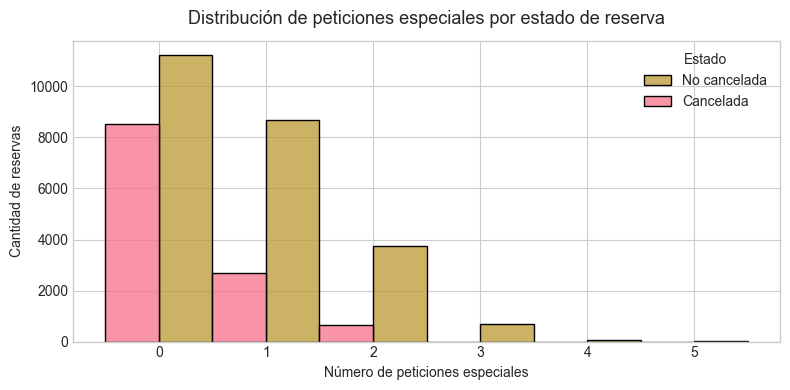

In [144]:
# Vas a necesitar RANDOM_SEED = 42 más adelante en la Sección 4 — el gráfico Plotly usa random_state=RANDOM_SEED (lo elimine arriba)
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=df,
    x='no_of_special_requests',
    hue='booking_status',
    multiple='dodge',
    discrete=True,
    ax=ax
)

ax.set_title('Distribución de peticiones especiales por estado de reserva',
             fontsize=13, pad=12)
ax.set_xlabel('Número de peticiones especiales')
ax.set_ylabel('Cantidad de reservas')
ax.legend(title='Estado', labels=['No cancelada', 'Cancelada'])
plt.tight_layout()
plt.savefig('../reports/viz1_distribucion_peticiones.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** [COMPLETAR] ¿Cómo se distribuyen las peticiones especiales entre canceladas y no canceladas? ¿Se observa ya a simple vista alguna diferencia en la proporción?

### Visualización 2 — Tasa de cancelación por número de peticiones especiales

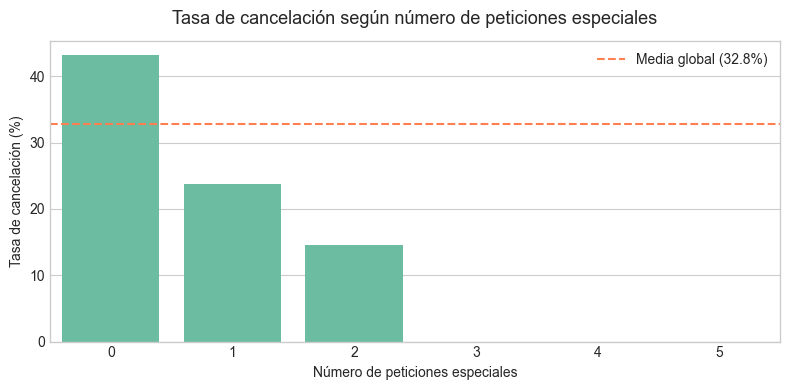

In [145]:
cancel_by_requests = df.groupby('no_of_special_requests')['is_canceled'].mean().reset_index()
cancel_by_requests.columns = ['no_of_special_requests', 'cancel_rate']
cancel_by_requests['cancel_rate_pct'] = cancel_by_requests['cancel_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=cancel_by_requests,
    x='no_of_special_requests',
    y='cancel_rate_pct',
    ax=ax,
    color='#5DCAA5'
)

ax.set_title('Tasa de cancelación según número de peticiones especiales',
             fontsize=13, pad=12)
ax.set_xlabel('Número de peticiones especiales')
ax.set_ylabel('Tasa de cancelación (%)')
ax.axhline(df['is_canceled'].mean() * 100, color='coral', linestyle='--',
           label=f'Media global ({df["is_canceled"].mean()*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/viz2_tasa_cancelacion_peticiones.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** [COMPLETAR] ¿Se observa una tendencia decreciente en la tasa de cancelación a medida que aumentan las peticiones especiales? ¿Es lineal o hay algún punto de inflexión?

### Visualización 3 — Distribución de precio por estado de cancelación

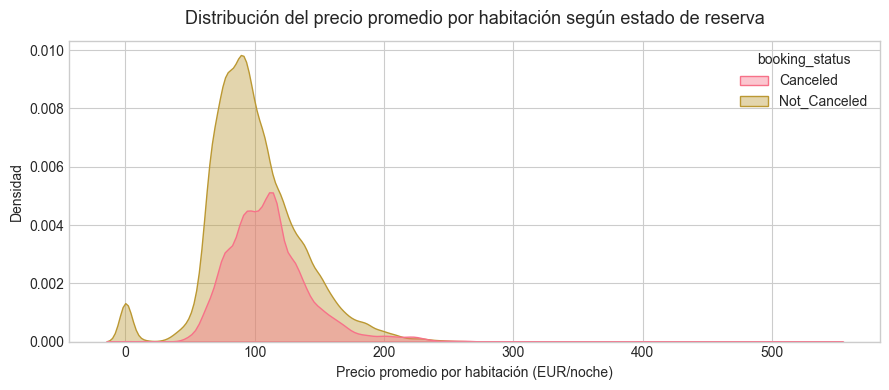

In [146]:
fig, ax = plt.subplots(figsize=(9, 4))

sns.kdeplot(
    data=df,
    x='avg_price_per_room',
    hue='booking_status',
    fill=True,
    alpha=0.4,
    ax=ax
)

ax.set_title('Distribución del precio promedio por habitación según estado de reserva',
             fontsize=13, pad=12)
ax.set_xlabel('Precio promedio por habitación (EUR/noche)')
ax.set_ylabel('Densidad')
plt.tight_layout()
plt.savefig('../reports/viz3_precio_cancelacion.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** [COMPLETAR] ¿Las reservas canceladas tienden a tener precios más altos o más bajos? ¿Las distribuciones se solapan mucho o hay diferencias claras?

### Visualización 4 — Mapa de calor de correlaciones

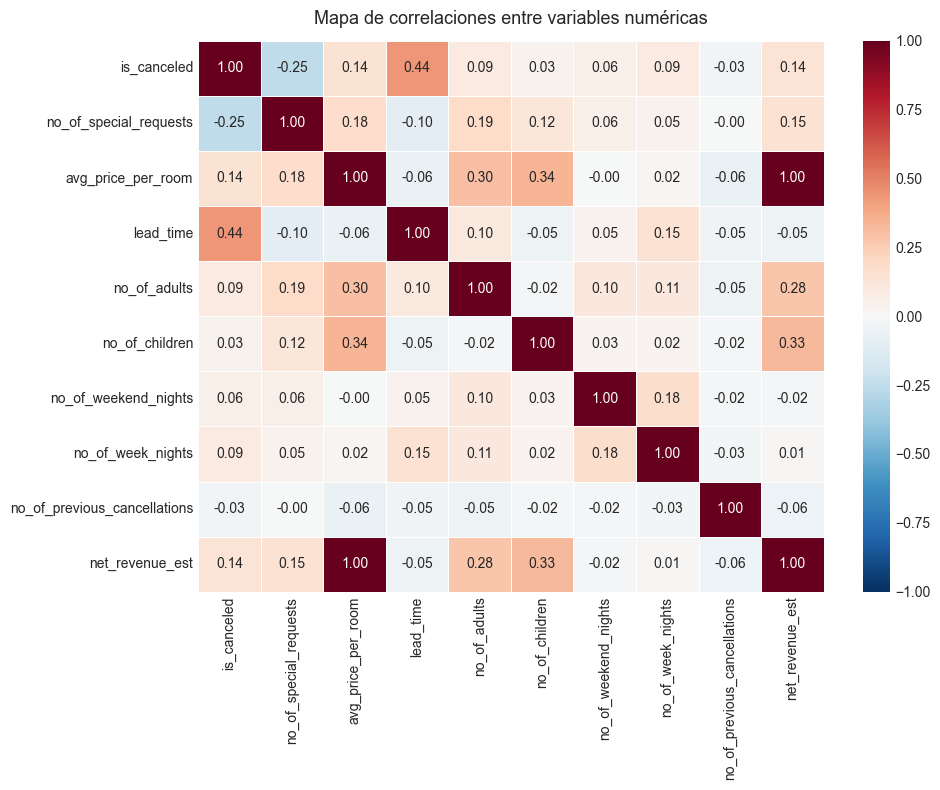

In [147]:
num_cols = ['is_canceled', 'no_of_special_requests', 'avg_price_per_room',
            'lead_time', 'no_of_adults', 'no_of_children',
            'no_of_weekend_nights', 'no_of_week_nights',
            'no_of_previous_cancellations', 'net_revenue_est']
num_cols = [c for c in num_cols if c in df.columns]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Mapa de correlaciones entre variables numéricas',
             fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../reports/viz4_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** [COMPLETAR] ¿Qué variables tienen mayor correlación con `is_canceled`? ¿Hay pares de variables predictoras con alta correlación entre sí (multicolinealidad potencial)? ¿Qué implica esto para el modelado?

### Visualización 5 — Gráfico interactivo (Plotly)

In [13]:
from IPython.display import HTML, display

fig_plotly = px.scatter(
    df.sample(n=5000, random_state=42),  # muestra para rendimiento
    x='lead_time',
    y='avg_price_per_room',
    color='booking_status',
    size='no_of_special_requests',
    size_max=12,
    hover_data=['market_segment_type', 'no_of_special_requests',
                'net_revenue_est', 'total_guests'],
    color_discrete_map={'Canceled': '#E24B4A', 'Not_Canceled': '#1D9E75'},
    labels={
        'lead_time': 'Antelación de la reserva (días)',
        'avg_price_per_room': 'Precio promedio por habitación (EUR/noche)',
        'booking_status': 'Estado de la reserva',
        'no_of_special_requests': 'Peticiones especiales'
    },
    title='Relación entre antelación, precio y cancelación<br><sup>Tamaño del punto = número de peticiones especiales (muestra de 5,000 reservas)</sup>'
)

fig_plotly.update_layout(
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    height=500
)

display(HTML(fig_plotly.to_html(full_html=False, include_plotlyjs='cdn')))

**Interpretación:** 

En el gráfico interactivo se observa un **solapamiento importante** entre reservas canceladas y no canceladas, por lo que no hay una separación perfecta en clusters solo con `lead_time` y `avg_price_per_room`. Sin embargo, sí aparece un patrón consistente: las reservas canceladas se concentran relativamente más en valores altos de antelación (`lead_time`) y en rangos de precio medio-alto.

Respecto al tamaño de los puntos, los más grandes (más peticiones especiales) se observan con mayor frecuencia en el grupo **Not_Canceled**, lo cual es coherente con las visualizaciones previas: las peticiones especiales funcionan como señal de compromiso del huésped y se asocian con menor probabilidad de cancelación.

---
## Sección 5 — Análisis Estadístico y Modelado (20%)

### 5.1 Prueba de independencia Chi-cuadrado

**Hipótesis:**
- H₀: El segmento de mercado (`market_segment_type`) y el estado de cancelación son independientes
- H₁: Existe dependencia estadística entre el segmento de mercado y la cancelación
- Nivel de significancia: α = 0.05

In [7]:
# Tabla de contingencia
contingency = pd.crosstab(
    df['market_segment_type'],
    df['booking_status'],
    margins=True
)
print('Tabla de contingencia:')
print(contingency)

# Tasas de cancelación por segmento
print('\nTasas de cancelación por segmento:')
cancel_by_segment = df.groupby('market_segment_type')['is_canceled'].mean() * 100
print(cancel_by_segment.sort_values(ascending=False).round(1))

Tabla de contingencia:
booking_status       Canceled  Not_Canceled    All
market_segment_type                               
Aviation                   37            88    125
Complementary               0           391    391
Corporate                 220          1797   2017
Offline                  3153          7375  10528
Online                   8475         14739  23214
All                     11885         24390  36275

Tasas de cancelación por segmento:
market_segment_type
Online           36.5
Offline          29.9
Aviation         29.6
Corporate        10.9
Complementary     0.0
Name: is_canceled, dtype: float64


In [8]:
# Chi-cuadrado
contingency_clean = pd.crosstab(df['market_segment_type'], df['booking_status'])

chi2, p_valor, gl, esperados = stats.chi2_contingency(contingency_clean)

print('── Resultados Chi-cuadrado ──────────────────')
print(f'Estadístico χ²:  {chi2:.4f}')
print(f'p-valor:         {p_valor:.6f}')
print(f'Grados libertad: {gl}')
print(f'\nDecisión (α=0.05): {"Rechazar H₀" if p_valor < 0.05 else "No rechazar H₀"}')

# Verificar supuesto: frecuencias esperadas ≥ 5
pct_menor_5 = (esperados < 5).sum() / esperados.size * 100
print(f'\nCelda con frecuencia esperada < 5: {pct_menor_5:.1f}% (supuesto OK si < 20%)')

── Resultados Chi-cuadrado ──────────────────
Estadístico χ²:  814.1089
p-valor:         0.000000
Grados libertad: 4

Decisión (α=0.05): Rechazar H₀

Celda con frecuencia esperada < 5: 0.0% (supuesto OK si < 20%)


**Interpretación:** Se **rechaza H₀** (χ² = 814.11, p < 0.001), por lo que existe dependencia estadísticamente significativa entre el segmento de mercado y la cancelación. 

Esto implica que el canal/segmento de reserva sí está asociado al riesgo de cancelar: no todos los segmentos se comportan igual. En particular, `Online` presenta la mayor tasa de cancelación (36.5%), por encima de la media global (~32.8%); `Offline` (29.9%) y `Aviation` (29.6%) quedan por debajo de la media; `Corporate` muestra una tasa mucho menor (10.9%) y `Complementary` prácticamente nula (0%). 

Además, el supuesto de frecuencias esperadas se cumple (0% de celdas con esperados < 5), por lo que la prueba es válida.

### 5.2 Regresión Logística

**Variable dependiente:** `is_canceled`  
**Variables independientes:** `no_of_special_requests`, `avg_price_per_room`, `lead_time`

In [9]:
# Preparar datos para el modelo
model_cols = ['no_of_special_requests', 'avg_price_per_room', 'lead_time']
df_model = df[model_cols + ['is_canceled']].dropna()

X = sm.add_constant(df_model[model_cols])  # añadir intercepto
y = df_model['is_canceled']

print(f'Observaciones en el modelo: {len(df_model):,}')
print(f'Variables: {model_cols}')

Observaciones en el modelo: 36,275
Variables: ['no_of_special_requests', 'avg_price_per_room', 'lead_time']


In [10]:
# Ajustar modelo logístico
logit_model = sm.Logit(y, X)
resultado = logit_model.fit(maxiter=200, disp=False)

print(resultado.summary())

                           Logit Regression Results                           
Dep. Variable:            is_canceled   No. Observations:                36275
Model:                          Logit   Df Residuals:                    36271
Method:                           MLE   Df Model:                            3
Date:                Fri, 08 May 2026   Pseudo R-squ.:                  0.2496
Time:                        22:25:24   Log-Likelihood:                -17216.
converged:                       True   LL-Null:                       -22944.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -3.4176      0.052    -65.236      0.000      -3.520      -3.315
no_of_special_requests    -1.0452      0.021    -49.345      0.000      -1.087      -1.004
avg_

In [11]:
# Odds ratios con intervalos de confianza al 95%
odds_ratios = pd.DataFrame({
    'Odds Ratio':    np.exp(resultado.params),
    'IC 95% inf':   np.exp(resultado.conf_int()[0]),
    'IC 95% sup':   np.exp(resultado.conf_int()[1]),
    'p-valor':      resultado.pvalues
}).round(4)

print('Odds Ratios (exp(coef)):')
print(odds_ratios)

print(f'\nPseudo R² (McFadden): {resultado.prsquared:.4f}')
print(f'AIC: {resultado.aic:.2f}')

Odds Ratios (exp(coef)):
                        Odds Ratio  IC 95% inf  IC 95% sup  p-valor
const                       0.0328      0.0296      0.0363      0.0
no_of_special_requests      0.3516      0.3373      0.3665      0.0
avg_price_per_room          1.0195      1.0186      1.0203      0.0
lead_time                   1.0131      1.0127      1.0134      0.0

Pseudo R² (McFadden): 0.2496
AIC: 34440.82


### Interpretación del modelo

El modelo logístico confirma que las tres variables incluidas son significativas (p < 0.001) y tienen el signo esperado:

- **`no_of_special_requests`**: OR = **0.3516**. Cada petición especial adicional reduce el *odds* de cancelación en aproximadamente **64.8%** (1 - 0.3516), manteniendo constantes las demás variables.
- **`avg_price_per_room`**: OR = **1.0195**. Por cada unidad adicional de precio, el *odds* de cancelación aumenta cerca de **1.95%**.
- **`lead_time`**: OR = **1.0131**. Cada día adicional de antelación incrementa el *odds* de cancelación en torno a **1.31%**.

En términos de ajuste, el **Pseudo R² (McFadden) = 0.2496**, que es un valor razonable/bueno para un modelo logístico en datos de comportamiento. También el AIC (34440.82) sirve como línea base para comparar versiones futuras del modelo.

**Limitación:** este modelo no incorpora variables categóricas (por ejemplo, `market_segment_type`) ni interacciones; una versión más completa debería incluir dummies de segmento y potencialmente interacciones con precio o antelación.

---
## Sección 6 — Uso de IA Documentado (5%)

### Herramienta utilizada: Claude (Anthropic) + Claude Code

A continuación se documenta de forma reflexiva el uso de inteligencia artificial en este proyecto.

| Momento | Qué se solicitó | Qué entregó la IA | Ajuste manual realizado |
|---|---|---|---|
| Definición del proyecto | Formular una pregunta analítica clara y verificable con el dataset hotelero | Propuso preguntas candidatas y una versión enfocada en cancelación vs. peticiones especiales | Se acotó el alcance para incluir moderación por precio y mantener viabilidad estadística |
| Sección 3 — Limpieza | Sugerir flujo reproducible de limpieza y feature engineering inicial | Estructura de nulos/duplicados/tipos + propuestas de variables derivadas | Se validaron decisiones con evidencia del dataset (p. ej., mantener precios = 0) y se ajustó redacción técnica |
| Sección 4 — EDA | Proponer visualizaciones para explorar la hipótesis principal | Ideas de histogramas, tasas por grupo, KDE, heatmap y gráfico interactivo | Se depuraron etiquetas, colores, guardado de figuras y se reescribieron interpretaciones con resultados reales |
| Sección 5 — Modelado | Guía para chi-cuadrado y regresión logística, con interpretación de OR | Esqueleto de pruebas, código base y criterios de lectura de resultados | Se ejecutó/validó en notebook, se corrigieron errores de entorno y se aterrizó interpretación con cifras concretas |
| README | Estructura de documentación reproducible del proyecto | Plantilla de secciones, pasos de ejecución y narrativa del problema | Se adaptó al contexto del curso, carpetas reales y decisiones metodológicas finales |

### Reflexión crítica

- La IA fue más útil para acelerar el diseño inicial del análisis y proponer estructuras reproducibles de trabajo (secciones, tablas y scripts base).
- Sí hubo errores o salidas incompletas: algunas interpretaciones quedaron genéricas o con placeholders, y en ejecución aparecieron detalles técnicos (por ejemplo, entorno de visualización) que requirieron intervención.
- La parte que más exigió trabajo manual fue la validación estadística y la traducción de resultados a conclusiones defendibles (evitar causalidad indebida, justificar decisiones de limpieza y explicar límites del modelo).
- En un próximo proyecto mantendría el uso de IA como copiloto, pero con una regla más estricta: no cerrar una sección sin evidencia ejecutada y revisión final de consistencia narrativa.

### Ejemplo concreto de uso y ajuste

Prompt usado (resumen): "Ayúdame a interpretar una regresión logística de cancelación con `no_of_special_requests`, `avg_price_per_room` y `lead_time`; explica OR, significancia y calidad del modelo".

Salida de IA: entregó una guía correcta a nivel conceptual (OR < 1 reduce odds; OR > 1 aumenta odds), pero en términos abstractos.

Ajuste manual: se reemplazó la redacción genérica por interpretación cuantitativa con resultados del notebook (OR=0.3516 para peticiones especiales, OR=1.0195 para precio, OR=1.0131 para lead time, pseudo R²=0.2496), y se añadió la limitación metodológica sobre variables categóricas e interacciones.

---
## Sección 7 — Conclusiones (10%)

### Respuesta a la pregunta de análisis

> **¿Existe una relación de dependencia estadística entre el número de peticiones especiales y la probabilidad de cancelación?**

Sí. La evidencia del notebook respalda una relación estadísticamente significativa entre señales de compromiso del huésped y cancelación, además de un efecto relevante del canal y la antelación:

- La prueba Chi-cuadrado mostró dependencia entre `market_segment_type` y cancelación (χ² = 814.11, p < 0.001).
- La regresión logística indica que cada petición especial adicional reduce el *odds* de cancelación en aproximadamente 64.8% (OR = 0.3516), manteniendo constantes precio y antelación.
- El precio y la antelación actúan como factores de riesgo incremental (OR precio = 1.0195; OR lead time = 1.0131), por lo que la cancelación responde a múltiples dimensiones del proceso de reserva.

### Hallazgos principales

1. `no_of_special_requests` es una señal fuerte de menor probabilidad de cancelación.
2. `lead_time` es uno de los predictores más influyentes de mayor riesgo de cancelar.
3. El segmento/canal de reserva no es neutro: `Online` concentra mayor tasa de cancelación que segmentos como `Corporate`.

### Limitaciones y sesgos del análisis

- **Causalidad vs. correlación:** El análisis es observacional. No podemos afirmar que las peticiones especiales *causan* menor cancelación — podría haber variables confusoras (tipo de viajero, propósito del viaje).
- **Dataset sintético:** El origen exacto de los datos no está completamente documentado. Los patrones encontrados pueden no generalizar a cualquier hotel.
- **Variables omitidas:** No se consideraron el historial del huésped, la temporada exacta, ni las condiciones del contrato de cancelación.
- **Modelo simple:** La regresión logística con 3 variables es un modelo de base. Un modelo más robusto incluiría variables categóricas y posiblemente interacciones.

### Recomendación de negocio

Implementar una estrategia de prevención de cancelación segmentada:

- Incentivar que el huésped complete al menos una petición especial durante la reserva (mejoras de habitación, preferencias de llegada, etc.), porque se asocia a mayor compromiso.
- Aplicar políticas de confirmación activa para reservas con alto `lead_time` (recordatorios, reconfirmación o incentivos por mantener la reserva).
- Diferenciar acciones por canal: en `Online`, reforzar mensajes de valor y mecanismos de retención temprana, dado su mayor riesgo de cancelación.

### Próximos pasos (Feature Engineering para modelos futuros)

Las variables creadas en la Sección 3 (`lead_time_bin`, `price_tier`, `has_special_request`, `net_revenue_est`) están diseñadas para alimentar modelos de mayor complejidad en iteraciones futuras:

- Regresión Logística con variables dummy de segmento de mercado
- Random Forest para ranking de importancia de variables
- XGBoost para predicción en producción